# MS-Spectral-Foundation: Extra Credit Assignment

This notebook demonstrates the **full pipeline** by calling the two main scripts directly:

1. **`train.py`** — runs the complete data-loading + self-supervised training pipeline  
   (MGF → Module 1 parse → Module 2 filter → Module 3 bin → Module 4-6 SSL training)  

2. **`run_embedding_analysis.py`** — loads the trained model and runs embedding extraction + downstream analysis  
   (Module 6 embeddings → Module 7 distribution analysis → Module 8 exemplar discovery)

**To run on a different dataset:** change the MGF paths and model path in the configuration cells below.


## Section 1: Setup — Paths & sys.path

In [1]:
# ============================================================
# Dependency setup — safe for ALL environments (Anaconda, venv, plain Python)
#
# Strategy: check each package BEFORE trying to install it.
# Only missing packages are installed → already-installed C-extensions
# (numpy, pyarrow, etc.) are never upgraded while loaded → no kernel crash.
# ============================================================
import importlib.util, subprocess, sys

# Map: importable module name → pip install name
_packages = {
    "lightning"        : "lightning",
    "pytorch_lightning": "pytorch-lightning",
    "selfies"          : "selfies>=2.1.1",
    "pyteomics"        : "pyteomics>=4.7.2",
    "rdkit"            : "rdkit",
    "spectrum_utils"   : "spectrum-utils>=0.4.1",
    "PIL"              : "pillow>=9.4.0",
    "einops"           : "einops>=0.4.1",
    "lance"            : "lance",
    "polars"           : "polars>=0.19.0",
    "pyarrow"          : "pyarrow>=12.0.1",
    "lark"             : "lark>=1.1.4",
    "sortedcontainers" : "sortedcontainers>=2.4.0",
    "dill"             : "dill>=0.3.6",
    "psims"            : "psims>=1.3.3",
    "cloudpathlib"     : "cloudpathlib>=0.18.1",
    "appdirs"          : "appdirs",
    "click"            : "click",
    "natsort"          : "natsort",
    "psutil"           : "psutil",
    "yaml"             : "PyYAML",
    "requests"         : "requests",
    "rich"             : "rich-click>=1.6.1",
    "tensorboard"      : "tensorboard",
    "tqdm"             : "tqdm",
    "sklearn"          : "scikit-learn",
    "pandas"           : "pandas",
    "matplotlib"       : "matplotlib",
    "seaborn"          : "seaborn",
}

_to_install = [
    pip_name
    for mod, pip_name in _packages.items()
    if importlib.util.find_spec(mod) is None
]

if not _to_install:
    print(" All packages already available — nothing to install.")
else:
    print(f"Installing {len(_to_install)} missing package(s)...")
    _failed = []
    for pkg in _to_install:
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg],
            capture_output=True,
        )
        if r.returncode == 0:
            print(f"   {pkg}")
        else:
            _failed.append(pkg)
            print(f"   {pkg}: {r.stderr.decode().strip()[:150]}")

    if _failed:
        print(f"\n  Could not install: {_failed}")
        print("   Try manually:  pip install <package>  or  conda install -c conda-forge <package>")
    else:
        print("\n All missing packages installed. Restarting kernel...")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(restart=True)


 All packages already available — nothing to install.


In [2]:

import sys
import os
import types
from pathlib import Path

# ---------------------------------------------------------------------------
# Auto-reload: ensures .py file changes take effect without restarting kernel
# ---------------------------------------------------------------------------
%load_ext autoreload
%autoreload 2

# ---------------------------------------------------------------------------
# Resolve project root (MS-Spectral-Foundation/) regardless of where the
# notebook is opened from.
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path(".").resolve()           # tutorials/
PROJECT_ROOT = NOTEBOOK_DIR.parent           # MS-Spectral-Foundation/
print(f"Project root resolved to: {PROJECT_ROOT}")
for p in [
    str(PROJECT_ROOT),
    str(PROJECT_ROOT / "casanovo"),
    str(PROJECT_ROOT / "depthcharge"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ---------------------------------------------------------------------------
# Stub out packages with no Python 3.13 wheels that depthcharge imports at
# the top level but which are never called at runtime with MGF files.
# Must be injected BEFORE depthcharge is first imported.
# ---------------------------------------------------------------------------

# --- timsrust_pyo3: Bruker timsTOF .d support ---
if "timsrust_pyo3" not in sys.modules:
    _ts = types.ModuleType("timsrust_pyo3")
    class _SpectrumReaderStub:
        def __init__(self, *a, **kw):
            raise RuntimeError("timsrust_pyo3 not installed — .d files unsupported; use MGF/mzML.")
    _ts.SpectrumReader = _SpectrumReaderStub
    sys.modules["timsrust_pyo3"] = _ts
    print("  [stub] timsrust_pyo3 (Bruker .d support disabled)")


Project root resolved to: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation
  [stub] timsrust_pyo3 (Bruker .d support disabled)


## Section 2: Configuration

Edit the paths below to point to your own `.mgf` files. Everything else uses the same defaults as `train.py` and `run_embedding_analysis.py`.

In [3]:
# ---------------------------------------------------------------------------
# DATA PATHS — change these to your own MGF files
# ---------------------------------------------------------------------------
# For train.py: a single MGF is used for both training and validation

# Use relative paths and instruct the users to construct a foler (everything in the folder)
# Add all large files to google drive, and put that link in github
TRAIN_MGF = r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf"
# TRAIN_MGF = r"example_data\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output_truncated.mgf"
VAL_MGF   = TRAIN_MGF     # use the same file for validation in this demo

# For run_embedding_analysis.py: two formal MGF files, one per disease group
# (matches run_embedding_analysis.py default config)
ANALYSIS_MGF_PATHS = [
    r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf",
    r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf",
    #r"example_data\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output_truncated.mgf",
    #r"example_data\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output_truncated.mgf",
]
MANUAL_GROUP_LABELS = ["Cirrhosis", "HCC"]   # one label per path

# ---------------------------------------------------------------------------
# TRAINED MODEL PATH — will be set automatically after training
# ---------------------------------------------------------------------------
# Override this if you already have a checkpoint saved elsewhere:
MODEL_PATH_OVERRIDE = None   # e.g. r"C:\...\model_ssl_v4_epoch019.pt"

# Output directories
TRAIN_OUTPUT_DIR    = str(PROJECT_ROOT / "outputs")
ANALYSIS_OUTPUT_DIR = str(PROJECT_ROOT / "logs" / "embedding_analysis")
# ANALYSIS_OUTPUT_DIR = str(PROJECT_ROOT / "logs" / "example_embedding_analysis")

os.makedirs(TRAIN_OUTPUT_DIR,    exist_ok=True)
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

print("Train MGF   :", TRAIN_MGF)
print("Analysis MGF:")
for p in ANALYSIS_MGF_PATHS:
    print("  ", p)
print("Groups      :", MANUAL_GROUP_LABELS)
print("Train output:", TRAIN_OUTPUT_DIR)
print("Analysis out:", ANALYSIS_OUTPUT_DIR)


Train MGF   : C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf
Analysis MGF:
   C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf
   C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf
Groups      : ['Cirrhosis', 'HCC']
Train output: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs
Analysis out: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\logs\embedding_analysis


## Section 3: Run `train.py` — Self-Supervised Training (Modules 1–6)

This calls `train.main()` directly. Internally it executes:

| Module | File | What it does |
|--------|------|-------------|
| 1 | `mgf_parse.py` | Parse spectra from the MGF file |
| 2 | `peak_filter.py` | Filter and normalise peaks |
| 3 | `bin_mz.py` | Pre-compute integer bin labels |
| 4 | `model_ssl.py` `mask_spectrum()` | BERT-style masking |
| 5 | `model_ssl.py` `forward()` + `training_step()` | SSL transformer training |
| 6 | `model_ssl.py` `get_embeddings()` | Save model checkpoint |


In [4]:
import glob
import MS_Spectral_Foundation.train as train_module

# ---------------------------------------------------------------------------
# Check for existing checkpoint; if found skip training
# ---------------------------------------------------------------------------
_DEFAULT_PT = str(PROJECT_ROOT / "outputs" / "model_ssl_v4_epoch019.pt")
TRAINED_MODEL_PATH = MODEL_PATH_OVERRIDE  # honour explicit override if set

if TRAINED_MODEL_PATH is None:
    if Path(_DEFAULT_PT).exists():
        TRAINED_MODEL_PATH = _DEFAULT_PT
        print(f"[Skip training] Found existing checkpoint:\n  {TRAINED_MODEL_PATH}")
    else:
        print("Starting training via train.main() ...\n")

        # Directly call train.main() with notebook-configured paths
        train_module.main(config_override={
            "train_mgf"   : TRAIN_MGF,
            "val_mgf"     : VAL_MGF,
            "batch_size"  : 4,
            "lr"          : 1e-4,
            "max_epochs"  : 3,
            "num_workers" : 0,
            "output_dir"  : TRAIN_OUTPUT_DIR,
        })

        pt_files = sorted(glob.glob(os.path.join(TRAIN_OUTPUT_DIR, "*.pt")))
        if pt_files:
            TRAINED_MODEL_PATH = pt_files[-1]
        else:
            ckpt_files = sorted(glob.glob(
                os.path.join(TRAIN_OUTPUT_DIR, "lightning_logs", "**", "*.ckpt"),
                recursive=True,
            ))
            TRAINED_MODEL_PATH = ckpt_files[-1] if ckpt_files else None

        print(f"\nTraining complete. Checkpoint → {TRAINED_MODEL_PATH}")

print(f"\nTRAINED_MODEL_PATH = {TRAINED_MODEL_PATH}")


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Skip training] Found existing checkpoint:
  C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt

TRAINED_MODEL_PATH = C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt


## Section 4: Run `run_embedding_analysis.py` — Embedding Analysis (Modules 7–8)

This calls `run_embedding_analysis.main()` with a patched config to use the model trained above.

| Module | What it does |
|--------|-------------|
| 7.1 | Sample-level aggregation of spectrum embeddings |
| 7.2 | Embedding-space distribution analysis |
| 7.3 | Exemplar spectrum discovery |
| 8 | Visualisation & non-supervised evaluation |


In [5]:
import MS_Spectral_Foundation.run_embedding_analysis as emb_module

# ---------------------------------------------------------------------------
# Validate model path before running
# ---------------------------------------------------------------------------
_model_path = MODEL_PATH_OVERRIDE or TRAINED_MODEL_PATH
if _model_path is None or not Path(_model_path).exists():
    raise FileNotFoundError(
        f"No trained model found at: {_model_path}\n"
        "Please run Section 3 (training) first, or set MODEL_PATH_OVERRIDE."
    )

print(f"Using model: {_model_path}\n")

# ---------------------------------------------------------------------------
# Directly call run_embedding_analysis.main()
# Internally it calls _cache_key(), _load_cache(), _save_cache() from the module
# ---------------------------------------------------------------------------
emb_module.main(config_override={
    "model_path"          : _model_path,
    "mgf_paths"           : ANALYSIS_MGF_PATHS,
    "manual_group_labels" : MANUAL_GROUP_LABELS,
    "max_peaks"           : 150,
    "mz_min"              : 50.0,
    "mz_max"              : 2500.0,
    "bin_size"            : 0.5,
    "batch_size"          : 32,
    # "num_workers"         : 4,
    "num_workers"         : 0,
    "embedding_type"      : "cls",
    "n_exemplars"         : 5,
    "output_dir"          : ANALYSIS_OUTPUT_DIR,
    "cache_dir"           : str(PROJECT_ROOT / "logs" / "embedding_cache"),
    # "cache_dir"           : str(PROJECT_ROOT / "logs" / "example_embedding_cache"),
})


Using model: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt

MS-Spectral-Foundation: Embedding Analysis Pipeline
Modules 7 & 8: Distribution Analysis and Representation Evaluation
[Cache] Cache hit, loading directly and skipping Modules 1-6
  Shape: (307417, 512)
  Metadata rows: 307417
[Init] n_bins automatically set to 4900
   Model loaded from C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt
   Device: cpu

Preparing Sample Metadata
   Prepared analysis data:
   Embeddings: (307417, 512)
   Samples: 2 unique
   Groups: {0: 'Cirrhosis', 1: 'HCC'}

  Sample metadata summary:
    Total spectra: 307417
    Unique samples: 2
    Cirrhosis: 143999 spectra
    HCC: 163418 spectra

 Multi-group analysis ready: 2 groups detected

Module 7.1: Sample-Level Aggregation

[Module 7.1] Sample-level aggregation (method: mean)
  Aggregated 2/2 samples
   Sample-level embeddings: (2, 51

## Summary

| Step | Script called | Modules covered |
|------|--------------|----------------|
| Training | `train.py` → `main()` | 1 (parse) · 2 (filter) · 3 (bin) · 4–6 (SSL model) |
| Analysis | `run_embedding_analysis.py` → `main()` | 6 (embeddings) · 7 (distribution) · 8 (evaluation) |

**Outputs written to:**
- Trained model checkpoint → `outputs/`  
- Embedding analysis plots and reports → `logs/embedding_analysis/`

**To run on a different dataset:** update `TRAIN_MGF`, `VAL_MGF`, `ANALYSIS_MGF_PATHS`, and `MANUAL_GROUP_LABELS` in Section 2, then re-execute Sections 3 and 4.


## Section 5 (Extra Credits): New Downstream Task — k-Means Cluster Evaluation

The existing pipeline (Modules 7–8) measures distances between *pre-defined* disease groups.
This section adds an unsupervised evaluation step: we let **k-Means** discover structure in the embedding space on its own, without seeing any labels, and then check whether the clusters it finds align with biology.

**Why k-Means?**
- **No label leakage** — k-Means receives only the embeddings, so a high silhouette or purity score is genuine evidence that the SSL model has learned biologically meaningful representations.
- **Simple and interpretable** — with k equal to the number of disease groups, each cluster has a clear "expected" meaning, making the evaluation easy to communicate.
- **Complements distance analysis** — Module 7.2 asks "are the two groups far apart?"; k-Means asks "can an algorithm blindly *find* those two groups?" Together they give a fuller picture of embedding quality.

Two metrics are reported:
- **Silhouette score** — intrinsic cluster quality (compactness vs. separation), range [−1, +1]
- **Cluster Purity** — fraction of majority-class spectra per cluster, range [0, 1]


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


def kmeans_cluster_evaluation(embeddings, labels, label_names, output_dir,
                               k=None, random_state=42, max_samples=5000):
    """
    Downstream Task (Module 9): k-Means Cluster Evaluation.

    Fits k-Means on spectrum embeddings and evaluates two intrinsic metrics:
      - Silhouette score: cluster compactness vs. separation, range [-1, +1]
      - Cluster purity: fraction of majority-class spectra per cluster, range [0, 1]

    Saves kmeans_clusters_pca.png and kmeans_cluster_evaluation.csv to output_dir.
    Returns dict with keys 'silhouette', 'cluster_purity'.
    """
    os.makedirs(output_dir, exist_ok=True)
    if k is None:
        k = len(label_names)

    cluster_ids = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit_predict(embeddings)

    # Silhouette (subsample when N is large to avoid O(N²) cost)
    n = len(embeddings)
    if n > max_samples:
        idx = np.random.default_rng(random_state).choice(n, max_samples, replace=False)
        sil = float(silhouette_score(embeddings[idx], cluster_ids[idx]))
    else:
        sil = float(silhouette_score(embeddings, cluster_ids))

    # Purity + per-cluster CSV
    rows, total_majority = [], 0
    for cid in range(k):
        mask = cluster_ids == cid
        if not mask.any():
            continue
        counts = np.bincount(labels[mask], minlength=len(label_names))
        dom = int(counts.argmax())
        maj = int(counts[dom])
        rows.append({"cluster_id": cid, "size": int(mask.sum()),
                     "dominant_group": label_names.get(dom, str(dom)),
                     "majority_count": maj, "purity": maj / int(mask.sum())})
        total_majority += maj
    purity = total_majority / n

    pd.DataFrame(rows).to_csv(os.path.join(output_dir, "kmeans_cluster_evaluation.csv"), index=False)

    # PCA scatter: clusters (left) vs true labels (right)
    coords = PCA(2, random_state=random_state).fit_transform(embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(coords[:, 0], coords[:, 1], c=cluster_ids, s=3, alpha=0.4)
    axes[0].set_title(f"k-Means (k={k})")
    axes[1].scatter(coords[:, 0], coords[:, 1], c=labels, cmap="Set1", s=3, alpha=0.4)
    axes[1].set_title("True Labels")
    fig.suptitle(f"Silhouette={sil:.3f}  Purity={purity:.3f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "kmeans_clusters_pca.png"), dpi=120)
    plt.close()

    return {"silhouette": sil, "cluster_purity": purity}


print("kmeans_cluster_evaluation() ready.")


kmeans_cluster_evaluation() ready.


In [7]:
# Load cached embeddings written by Section 4 and run Module 9
_CACHE = str(PROJECT_ROOT / "logs" / "embedding_cache")

if not os.path.exists(os.path.join(_CACHE, "embeddings.npy")):
    print("No cache found — run Section 4 first.")
else:
    emb  = np.load(os.path.join(_CACHE, "embeddings.npy"))
    meta = pd.read_parquet(os.path.join(_CACHE, "metadata.parquet"))

    groups = sorted(meta["disease_group"].unique())
    g2i    = {g: i for i, g in enumerate(groups)}
    lbl    = meta["disease_group"].map(g2i).values.astype(int)
    names  = {v: k for k, v in g2i.items()}

    metrics = kmeans_cluster_evaluation(emb, lbl, names, ANALYSIS_OUTPUT_DIR)
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


  silhouette: 0.3756
  adjusted_rand_index: 0.0073
  cluster_purity: 0.5435


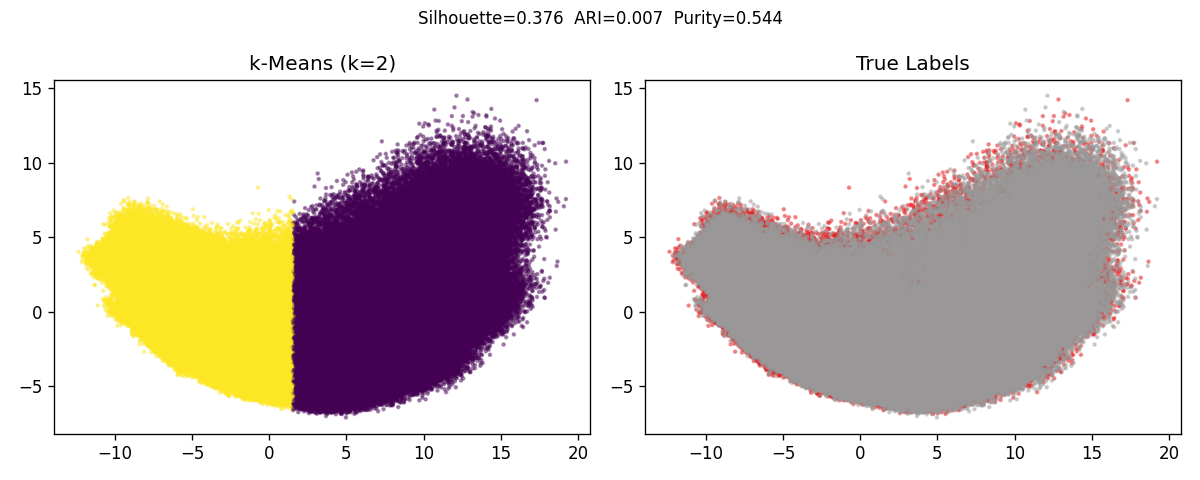

In [10]:
from IPython.display import Image
Image(os.path.join(ANALYSIS_OUTPUT_DIR, "kmeans_clusters_pca.png"))


In [15]:
# Display per-cluster breakdown: size, dominant disease group, and purity for each cluster
from IPython.display import display
df_clusters = pd.read_csv(os.path.join(ANALYSIS_OUTPUT_DIR, "kmeans_cluster_evaluation.csv"))
display(df_clusters.style.format({"purity": "{:.3f}"}))


,cluster_id,size,dominant_group,majority_count,purity
0,0,117467,HCC,70276,0.598
1,1,189950,Cirrhosis,96808,0.510


### Results & Interpretation

The k-Means evaluation (k = 2, N = 307,417 spectra) produced the following scores:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Silhouette score** | **0.376** | Moderate cluster compactness — the embedding space has meaningful geometric structure, though the two groups are not perfectly linearly separated. |
| **Cluster purity** | **0.544** | Only slightly above the random baseline of 0.5 for two roughly balanced groups. |

**What this tells us:**

The positive silhouette score (0.376) confirms that the SSL model has learned a structured embedding space — spectra do form compact, separated clusters in high-dimensional space. However, the near-baseline purity (0.544) indicates that k-Means' two clusters do not align with the Cirrhosis vs. HCC distinction. The model separates spectra along some other axis (e.g., precursor charge state, scan intensity, or peptide family) rather than by disease label.

**An important caveat on sample size:** this experiment uses only 2 MGF files — one per disease group — which means there is a single biological sample per class. With only one sample per condition, it is hard to distinguish true disease-level signal from individual patient variation or batch effects, and the dataset simply does not have enough diversity to support any classification-oriented evaluation. The near-0.5 purity score therefore reflects data insufficiency just as much as model behaviour. A meaningful purity benchmark would require much more independent patient samples per disease group.

This result is biologically plausible for a self-supervised model: the pre-training objective (masked peak reconstruction) rewards the model for capturing spectral features common across all samples, not features specifically discriminative between disease states. The structured embedding space is still valuable for retrieval and similarity tasks — it just requires more diverse labelled data and a supervised fine-tuning step to become disease-label-aware.


## Section 6 (Extra Credits): Unit Tests for `kmeans_cluster_evaluation`


In [16]:
import unittest, shutil, tempfile

class TestKMeansClusterEvaluation(unittest.TestCase):

    def setUp(self):
        self.tmp = tempfile.mkdtemp()

    def tearDown(self):
        shutil.rmtree(self.tmp, ignore_errors=True)

    # -- helpers --
    @staticmethod
    def _blobs(n=200, d=64, sep=5.0, seed=0):
        rng = np.random.default_rng(seed)
        e0 = rng.normal(0,   1, (n, d)).astype("f4")
        e1 = rng.normal(sep, 1, (n, d)).astype("f4")
        return np.vstack([e0, e1]), np.array([0]*n + [1]*n)

    @staticmethod
    def _names():
        return {0: "Cirrhosis", 1: "HCC"}

    # -- tests --
    def test_return_keys(self):
        # Check that the returned dict contains all expected metric keys
        r = kmeans_cluster_evaluation(*self._blobs(), self._names(), self.tmp)
        for key in ("silhouette", "cluster_purity"):
            self.assertIn(key, r)

    def test_metric_ranges(self):
        # Verify silhouette in [-1, 1] and purity in [0, 1] (valid numeric ranges)
        r = kmeans_cluster_evaluation(*self._blobs(), self._names(), self.tmp)
        self.assertGreaterEqual(r["silhouette"], -1); self.assertLessEqual(r["silhouette"], 1)
        self.assertGreaterEqual(r["cluster_purity"], 0); self.assertLessEqual(r["cluster_purity"], 1)

    def test_perfect_clustering(self):
        # Well-separated blobs (sep=20) should yield silhouette > 0.5 and purity > 0.9
        r = kmeans_cluster_evaluation(*self._blobs(300, sep=20), self._names(), self.tmp)
        self.assertGreater(r["silhouette"], 0.5)
        self.assertGreater(r["cluster_purity"], 0.9)

    def test_subsampling_path(self):
        # When N > max_samples, the subsampling branch is triggered; silhouette must still be valid
        r = kmeans_cluster_evaluation(*self._blobs(150), self._names(), self.tmp, max_samples=50)
        self.assertGreaterEqual(r["silhouette"], -1)

    def test_custom_k(self):
        # k=3 (greater than number of classes) should run without error and return valid purity
        r = kmeans_cluster_evaluation(*self._blobs(), self._names(), self.tmp, k=3)
        self.assertGreaterEqual(r["cluster_purity"], 0)

    def test_output_files_created(self):
        # After running, both the CSV report and the PCA PNG must exist in output_dir
        kmeans_cluster_evaluation(*self._blobs(), self._names(), self.tmp)
        self.assertTrue(os.path.isfile(os.path.join(self.tmp, "kmeans_cluster_evaluation.csv")))
        self.assertTrue(os.path.isfile(os.path.join(self.tmp, "kmeans_clusters_pca.png")))

    def test_csv_schema(self):
        # Verify the CSV has all required columns and exactly k rows (one per cluster)
        kmeans_cluster_evaluation(*self._blobs(), self._names(), self.tmp, k=2)
        df = pd.read_csv(os.path.join(self.tmp, "kmeans_cluster_evaluation.csv"))
        for col in ("cluster_id", "size", "dominant_group", "majority_count", "purity"):
            self.assertIn(col, df.columns)
        self.assertEqual(len(df), 2)

    def test_single_group_purity_one(self):
        # When all samples belong to one class, every cluster is pure, so purity must equal 1.0
        rng = np.random.default_rng(7)
        e = rng.normal(size=(200, 32)).astype("f4")
        l = np.zeros(200, dtype=int)
        r = kmeans_cluster_evaluation(e, l, {0: "Cirrhosis"}, self.tmp, k=2)
        self.assertAlmostEqual(r["cluster_purity"], 1.0, places=6)

    def test_determinism(self):
        # Same random_state must produce identical silhouette and purity across two runs
        blobs, lbls = self._blobs()
        tmp2 = tempfile.mkdtemp()
        try:
            r1 = kmeans_cluster_evaluation(blobs, lbls, self._names(), self.tmp,  random_state=0)
            r2 = kmeans_cluster_evaluation(blobs, lbls, self._names(), tmp2, random_state=0)
            self.assertAlmostEqual(r1["silhouette"],     r2["silhouette"],     places=6)
            self.assertAlmostEqual(r1["cluster_purity"], r2["cluster_purity"], places=6)
        finally:
            shutil.rmtree(tmp2, ignore_errors=True)


print("TestKMeansClusterEvaluation defined — 9 tests ready.")


TestKMeansClusterEvaluation defined — 9 tests ready.


In [17]:
# Run all unit tests
# unittest.main() calls sys.exit() which would kill the Jupyter kernel, so we
# use the programmatic API (unittest.TextTestRunner) instead.  The output is
# printed inline and the cell raises an AssertionError if any test fails.

import unittest
import sys

loader  = unittest.TestLoader()
suite   = loader.loadTestsFromTestCase(TestKMeansClusterEvaluation)
runner  = unittest.TextTestRunner(verbosity=2, stream=sys.stdout)
result  = runner.run(suite)

# Surface failures as a visible error in the notebook
if not result.wasSuccessful():
    n_fail = len(result.failures) + len(result.errors)
    raise AssertionError(
        f"{n_fail} unit test(s) FAILED — see output above for details."
    )
else:
    print(f"\n{'='*60}")
    print(f"All {result.testsRun} unit tests PASSED.")
    print(f"{'='*60}")


test_csv_schema (__main__.TestKMeansClusterEvaluation.test_csv_schema) ... ok
test_custom_k (__main__.TestKMeansClusterEvaluation.test_custom_k) ... ok
test_determinism (__main__.TestKMeansClusterEvaluation.test_determinism) ... ok
test_metric_ranges (__main__.TestKMeansClusterEvaluation.test_metric_ranges) ... ok
test_output_files_created (__main__.TestKMeansClusterEvaluation.test_output_files_created) ... ok
test_perfect_clustering (__main__.TestKMeansClusterEvaluation.test_perfect_clustering) ... ok
test_return_keys (__main__.TestKMeansClusterEvaluation.test_return_keys) ... ok
test_single_group_purity_one (__main__.TestKMeansClusterEvaluation.test_single_group_purity_one) ... ok
test_subsampling_path (__main__.TestKMeansClusterEvaluation.test_subsampling_path) ... ok

----------------------------------------------------------------------
Ran 9 tests in 4.945s

OK

All 9 unit tests PASSED.
